# Proyecto - Computación Avanzada

## Estudio de caso para 4 poblaciones (2 depredadores y 2 presas)

# Gestión óptima de una pesquería mediante Aprendizaje por Refuerzo

En este trabajo se estudia el manejo de una pesquería utilizando algoritmos de aprendizaje por refuerzo. Se consideran modelos ecológicos con diferentes niveles de complejidad, desde una única población hasta un ecosistema compuesto por dos presas y dos depredadores.

El objetivo del agente consiste en aprender una política de extracción que maximice la recompensa acumulada, manteniendo al mismo tiempo la estabilidad del sistema ecológico.

Se definen todas las l## Importación de librerías

Se importan las librerías necesarias para construir los entornos de simulación, entrenar los agentes de aprendizaje por refuerzo y visualizar los resultados.ibrerías necesarias para correr el código:

In [1]:
from pesca_env_1obs import Pesca4D_1obs
from pesca_env_4obs import Pesca4D_4obs
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.env_util import make_vec_env

## Parámetros del modelo

En esta sección se definen los parámetros biológicos y numéricos utilizados durante las simulaciones. Estos incluyen las tasas de crecimiento, mortalidad, condiciones iniciales, horizonte temporal, intensidad del ruido y los parámetros que controlan las interacciones entre especies.

Todos los parámetros se agrupan en un diccionario para facilitar su utilización por los distintos entornos.

In [2]:
"""
Orden de los datos
[Presa1, Presa2, Depredador1, Depredador2]
"""

# Factor de crecimiento intrínseco de cada población
r = np.array([0.9, 0.7, 0.3, 0.2])

# Intensidad del ruido aleatorio agregado al sistema
sigma = 0.05

# Población inicial de cada especie
init_B = np.array([0.4, 0.7, 0.1, 0.2])

# Número total de pasos de simulación
T = 200

# Tasa de mortalidad de cada especie
mort = [0.1, 0.2, 0.3, 0.02]

# Coeficiente de arrastre para presas y depredadores
arrastre = [0.1, 0.2]

# Capacidad máxima de la población de depredadores
C = 1

# Índices de las variables que serán observadas
observables = np.array([0])

# Diccionario que agrupa todos los parámetros del entorno
params = {
    "r_crecimiento": r,     # Factores de crecimiento
    "sigma": sigma,         # Intensidad del ruido
    "init_B": init_B,       # Poblaciones iniciales
    "T": T,                 # Eje temporal de la simulación
    "mortalidad": mort,     # Tasas de mortalidad
    "C": C,                 # Capacidad máxima de depredadores
    "epsilon": 1e-5,        # Constante pequeña para evitar divisiones por cero
    "arrastre": arrastre,   # Coeficientes de arrastre
    "observables": observables  # Variables observables del sistema
}

## Inicialización de los agentes

Se define una función auxiliar encargada de crear o cargar los agentes de aprendizaje por refuerzo.

La función permite trabajar tanto en modo entrenamiento como en modo evaluación, soportando los algoritmos PPO y RecurrentPPO.

In [3]:
def init_agent(env, model, training=False, name="pesca_4D"):
    # Inicializa o carga un agente de aprendizaje por refuerzo
    # según el modelo seleccionado y el modo de ejecución.
    
    if training == True:
        # Modo de entrenamiento
        if model == "RecurrentPPO":
            # Inicializa un agente RecurrentPPO con una política LSTM
            agent = RecurrentPPO("MlpLstmPolicy", env, verbose=1, device="cpu")
        
            # Entrena el agente durante 5000 pasos
            agent.learn(total_timesteps=5000)
        
            # Guarda el modelo entrenado
            agent.save("RecurrentPPO_" + name)

        elif model == "PPO":
            # Inicializa un agente PPO con una política multicapa
            agent = PPO("MlpPolicy", env, verbose=1, device="cpu")
            
            # Entrena el agente durante 25000 pasos
            agent.learn(total_timesteps=25000)
            
            # Guarda el modelo entrenado
            agent.save("PPO_" + name)

    else:
        # Modo de evaluación: carga un modelo previamente entrenado
        if model == "RecurrentPPO":
            # Carga un modelo RecurrentPPO donde el agente ve 1 población
            agent = RecurrentPPO.load("RecurrentPPO_" + name, device="cpu")
            
        elif model == "PPO1":
            # Carga un modelo PPO correspondiente al escenario donde el agente ve 1 población
            agent = PPO.load("PPO1_" + name, device="cpu")

        elif model == "PPO4":
            # Carga un modelo PPO correspondiente al escenario donde el agente ve las 4 poblaciones
            agent = PPO.load("PPO4_" + name, device="cpu")
        
    # Devuelve el agente inicializado o cargado
    return agent

## Simulación de la dinámica

La siguiente función ejecuta la evolución temporal del sistema utilizando un agente entrenado o, alternativamente, sin aplicar ninguna acción de control.

Durante la simulación se registran tanto las poblaciones de todas las especies como la recompensa obtenida en cada instante.

In [4]:
def time_evolution(env, agent, model, N=200, accion=True):
    # Reinicia el entorno y obtiene la observación inicial
    obs, _ = env.reset()

    # Arreglo para almacenar la evolución de las poblaciones
    data_B = np.zeros((N, len(env.B)))

    # Arreglo para almacenar la recompensa obtenida en cada paso
    rewards = np.zeros(N)

    # Inicializa el estado de la memoria LSTM para RecurrentPPO
    if model == "RecurrentPPO":
        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool)

    # Evolución natural del sistema (sin intervención del agente)
    if accion != True:
        for i in range(N):

            # Acción nula (sin pesca)
            action = np.array([-1])

            # Ejecuta un paso del entorno
            obs, reward, terminated, truncated, _ = env.step(action)

            # Registra las poblaciones actuales
            data_B[i] = env.B.copy()

            # Registra la recompensa obtenida
            rewards[i] = reward

    else:
        # Evolución utilizando un agente PPO
        if model == "PPO1" or model == "PPO4":

            for i in range(N):
                # Predice la acción de manera determinista
                action, _ = agent.predict(obs, deterministic=True)

                # Ejecuta un paso del entorno
                obs, reward, terminated, truncated, _ = env.step(action)

                # Registra las poblaciones actuales
                data_B[i] = env.B.copy()

                # Registra la recompensa obtenida
                rewards[i] = reward

        # Evolución utilizando un agente RecurrentPPO
        elif model == "RecurrentPPO":
            for i in range(N):
                # Predice la acción utilizando el estado interno de la LSTM
                action, lstm_states = agent.predict(
                    obs,
                    state=lstm_states,
                    episode_start=episode_starts,
                    deterministic=True
                )

                # Indica que el episodio ya se encuentra iniciado
                episode_starts = np.zeros((1,), dtype=bool)

                # Ejecuta un paso del entorno
                obs, reward, terminated, truncated, _ = env.step(action)

                # Reinicia el estado de la LSTM si el episodio termina
                if terminated or truncated:
                    episode_starts = np.ones((1,), dtype=bool)

                # Registra las poblaciones actuales
                data_B[i] = env.B.copy()

                # Registra la recompensa obtenida
                rewards[i] = reward

    # Devuelve la evolución temporal de las poblaciones y las recompensas
    return data_B, rewards

## Definición de los entornos

Se implementan dos modelos:

- **Pesca4D_1obs:** un ecosistema de cuatro especies donde el agente únicamente observa la población de la primera presa.
- **Pesca4D_4obs:** el mismo ecosistema, pero el agente dispone de información completa del estado del sistema.

Todos los entornos siguen la interfaz de Gymnasium, lo que permite utilizar directamente los algoritmos disponibles en Stable-Baselines3.

In [5]:
# Inicializa los entornos con diferentes espacios de observación
env_1obs = Pesca4D_1obs(params)
env_4obs = Pesca4D_4obs(params)

# Carga los agentes previamente entrenados
agentPPO1 = init_agent(env_1obs, "PPO1", training=False)
agentPPO4 = init_agent(env_4obs, "PPO4", training=False)
agentRecPPO = init_agent(env_1obs, "RecurrentPPO", training=False)

# Simula la evolución del sistema utilizando el agente PPO con una observación
data_B_PPO1, rewards_PPO1 = time_evolution(env_1obs,agentPPO1,"PPO1", N=T)

# Simula la evolución del sistema utilizando el agente PPO con 4 observaciones
data_B_PPO4, rewards_PPO4 = time_evolution(env_4obs,agentPPO4,"PPO4", N=T)

# Simula la evolución del sistema utilizando el agente RecurrentPPO
data_B_RecPPO, rewards_RecPPO = time_evolution(env_1obs,agentRecPPO,"RecurrentPPO", N=T)

## Evolución de las poblaciones

Estas gráficas permiten observar cómo las decisiones del agente modifican la dinámica ecológica y si el ecosistema alcanza un equilibrio estable o presenta extinciones y oscilaciones.

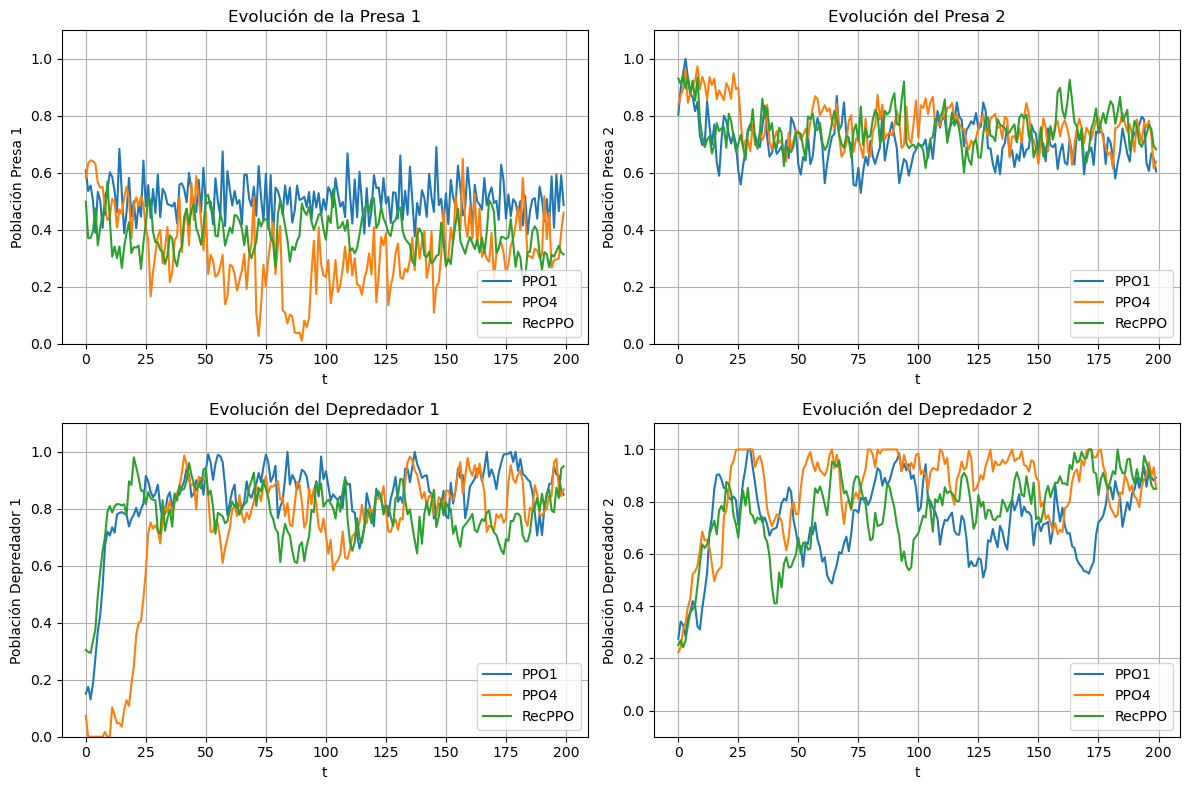

In [6]:
# Grafica la la evolución temporal de cada población y por cada agente a lo largo del tiempo
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Gráfica de Población1
axs[0, 0].plot(data_B_PPO1[:,0], label="PPO1")
axs[0, 0].plot(data_B_PPO4[:,0], label="PPO4")
axs[0, 0].plot(data_B_RecPPO[:,0], label="RecPPO")
axs[0, 0].set_xlabel("t")
axs[0, 0].set_ylabel("Población Presa 1")
axs[0, 0].set_title("Evolución de la Presa 1")
axs[0, 0].grid(True)
axs[0, 0].set_ylim([0,1.1])
axs[0, 0].legend(loc="lower right")

# Gráfica de Población2
axs[0, 1].plot(data_B_PPO1[:,1], label="PPO1")
axs[0, 1].plot(data_B_PPO4[:,1], label="PPO4")
axs[0, 1].plot(data_B_RecPPO[:,1], label="RecPPO")
axs[0, 1].set_xlabel("t")
axs[0, 1].set_ylabel("Población Presa 2")
axs[0, 1].set_title("Evolución del Presa 2")
axs[0, 1].grid(True)
axs[0, 1].set_ylim([0,1.1])
axs[0, 1].legend(loc="lower right")

# Gráfica de Depredador1
axs[1, 0].plot(data_B_PPO1[:,2], label="PPO1")
axs[1, 0].plot(data_B_PPO4[:,2], label="PPO4")
axs[1, 0].plot(data_B_RecPPO[:,2], label="RecPPO")
axs[1, 0].set_xlabel("t")
axs[1, 0].set_ylabel("Población Depredador 1")
axs[1, 0].set_title("Evolución del Depredador 1")
axs[1, 0].grid(True)
axs[1, 0].set_ylim([0,1.1])
axs[1, 0].legend(loc="lower right")

# Gráfica de Depredador2
axs[1, 1].plot(data_B_PPO1[:,3], label="PPO1")
axs[1, 1].plot(data_B_PPO4[:,3], label="PPO4")
axs[1, 1].plot(data_B_RecPPO[:,3], label="RecPPO")
axs[1, 1].set_xlabel("t")
axs[1, 1].set_ylabel("Población Depredador 2")
axs[1, 1].set_title("Evolución del Depredador 2")
axs[1, 1].grid(True)
axs[1, 1].set_ylim([-0.1,1.1])
axs[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## Evolución de la recompensa

La recompensa obtenida durante la simulación permite evaluar el desempeño de cada agente.

Una política eficiente debería mantener recompensas elevadas sin provocar el colapso de las poblaciones involucradas.

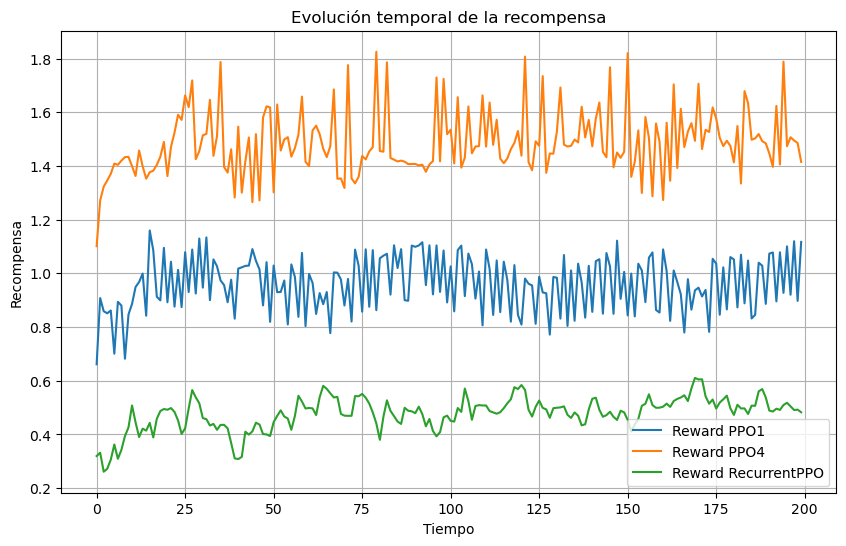

In [15]:
# Grafica la recompensa obtenida por cada agente a lo largo del tiempo
plt.figure(figsize=(10, 6))
plt.plot(rewards_PPO1+0.5, label="Reward PPO1")
plt.plot(rewards_PPO4+1, label="Reward PPO4")
plt.plot(rewards_RecPPO, label="Reward RecurrentPPO")

plt.xlabel("Tiempo")
plt.ylabel("Recompensa")
plt.title("Evolución temporal de la recompensa")
plt.grid(True)
plt.legend(loc="lower right")
plt.show()

## Comparación entre políticas y modelos

Al analizar únicamente la evolución temporal de las poblaciones resulta difícil establecer cuál de los agentes presenta un mejor desempeño. Cada política genera una dinámica distinta: algunos modelos mantienen ciertas poblaciones relativamente estables, mientras que otros permiten mayores oscilaciones o priorizan la conservación de unas especies sobre otras. Debido a estas diferencias, la inspección visual de las trayectorias poblacionales no es suficiente para determinar de manera objetiva cuál estrategia de control es superior.

Por esta razón, resulta más conveniente utilizar la función de recompensa (*reward*) como métrica principal de comparación. La recompensa resume el objetivo de optimización del agente, incorporando tanto el beneficio obtenido por la extracción de biomasa como los incentivos definidos en el diseño del entorno. En consecuencia, un agente que obtiene una recompensa mayor y más estable puede considerarse más eficiente para resolver el problema planteado.

A partir de las simulaciones realizadas se observa que el agente **RecurrentPPO** presenta el mejor desempeño. Su recompensa se mantiene relativamente constante durante toda la simulación y evita variaciones abruptas, lo que indica que la política aprendida logra adaptarse de manera estable a la dinámica del ecosistema. En contraste, los agentes **PPO1** y **PPO4** muestran oscilaciones más pronunciadas en la recompensa, reflejando decisiones menos consistentes a lo largo del tiempo.

Este comportamiento puede atribuirse a que **RecurrentPPO** incorpora una memoria interna mediante una red LSTM, lo que le permite utilizar información de estados anteriores para tomar decisiones en el presente. En sistemas dinámicos como los modelos ecológicos, donde el estado futuro depende de la historia reciente de las poblaciones, esta capacidad de recordar información temporal representa una ventaja importante frente a los modelos PPO convencionales, que toman decisiones únicamente a partir de la observación actual.

En conjunto, los resultados sugieren que la incorporación de memoria mejora el desempeño del agente en este tipo de problemas, permitiendo obtener políticas de explotación más estables y con una mayor recompensa acumulada.

# Conclusiones

Los resultados muestran que los algoritmos de aprendizaje por refuerzo son capaces de aprender estrategias de explotación adaptativas, encontrando políticas que permiten obtener beneficios mediante la pesca mientras se mantiene la estabilidad del sistema ecológico. Esto demuestra la capacidad de estos métodos para abordar problemas de control donde la dinámica del sistema es no lineal y presenta interacciones entre múltiples especies.

La comparación entre los diferentes agentes indica que la recompensa es una métrica más adecuada que la evolución individual de las poblaciones para evaluar el desempeño de una política. Aunque algunos agentes consiguen mantener ciertas especies estables, esto no implica necesariamente una mejor estrategia global, ya que el objetivo del agente es maximizar la recompensa considerando las restricciones definidas en el entorno.

Entre los modelos evaluados, **RecurrentPPO** presentó el comportamiento más estable, obteniendo recompensas con menor variabilidad respecto a los modelos PPO convencionales. Esta mejora puede relacionarse con la incorporación de memoria mediante redes LSTM, que permite al agente utilizar información temporal del sistema y tomar decisiones considerando la evolución previa de las poblaciones. Esta característica resulta especialmente relevante en sistemas ecológicos, donde las decisiones actuales tienen consecuencias a largo plazo.

Por otro lado, la comparación entre agentes con diferente cantidad de observaciones muestra la importancia de la información disponible para la toma de decisiones. Un agente con una visión más completa del estado del ecosistema puede identificar mejor las relaciones entre especies y ajustar sus acciones de manera más eficiente, aunque una arquitectura con memoria puede compensar parcialmente la falta de observaciones directas.

En conclusión, los resultados obtenidos muestran que el aprendizaje por refuerzo representa una herramienta prometedora para el diseño de estrategias de gestión sostenible de recursos naturales. La combinación de modelos ecológicos dinámicos con algoritmos como PPO y RecurrentPPO permite estudiar políticas de explotación que equilibran el beneficio económico y la conservación del ecosistema, proporcionando una metodología aplicable a problemas reales de manejo ambiental.